# ResNet50V2 + LightGBM Hybrid -- Sharmin et al. (2023)
IEEE Access, 2023. Combines ResNet50V2 feature extraction with a Light Gradient Boosting (LightGBM)
classifier -- reported 95% accuracy on IDC positive/negative classification.

**Adapted to your pipeline:**
- The paper's task is binary (IDC positive/negative); extended here to your 3-class problem
  (Benign/Malignant/Normal) using LightGBM's native multiclass objective.
- This is a genuine two-stage hybrid, not a plain CNN: ResNet50V2 acts ONLY as a frozen feature
  extractor (no dense classification head, no backprop through it) -- the actual classification
  decision is made entirely by LightGBM on the extracted feature vectors. This matches the paper's
  design, where 'ResNet50V2 feature extraction with a Light Gradient Boosting (LGB) classifier
  yields superior performance' rather than fine-tuning ResNet50V2 end-to-end.
- LightGBM is a separate library (not TensorFlow) -- this is expected and matches the paper; only
  the feature-extraction stage runs in TensorFlow.

In [1]:
# ==========================================================
# INSTALL LIGHTGBM (only needed once per environment)
# ==========================================================
# !pip install lightgbm

print("start")

import os

DATASET_PATH = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

print("Balanced dataset ready")


start
Balanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# GPU MEMORY GROWTH
# ==========================================================
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth enabled on {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


Memory growth enabled on 1 GPU(s)


In [4]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

print("done1")


start
done1


In [5]:
# ==========================================================
# CONFIGURATION
# ==========================================================
print("start")

IMAGE_SIZE = (288, 288)          # 32-divisible; consistent with your other notebooks
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 16

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print("done1")


start
done1


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_flow = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False    # shuffle=False here -- we need feature/label order to line up exactly
                      # when extracting features for LightGBM below
)

val_flow = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_flow = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes found:", train_flow.class_indices)


Found 18000 images belonging to 3 classes.
Found 2965 images belonging to 3 classes.
Found 2943 images belonging to 3 classes.
Classes found: {'Benign': 0, 'Malignant': 1, 'Normal': 2}


In [7]:
# ==========================================================
# BUILD RESNET50V2 FEATURE EXTRACTOR (frozen, no classification head)
# ==========================================================
print("start")

base_model = ResNet50V2(
    input_shape=MODEL_INPUT_SIZE,
    weights='imagenet',
    include_top=False
)
base_model.trainable = False

feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

feature_extractor.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [8]:
# ==========================================================
# EXTRACT DEEP FEATURES FOR TRAIN / VAL / TEST
# ==========================================================
# LightGBM needs the full feature matrix in memory (not a generator), so we run
# ResNet50V2 once over each split and cache the resulting feature vectors + labels.

def extract_features(flow, name):
    steps = len(flow)
    flow.reset()
    features = feature_extractor.predict(flow, steps=steps, verbose=1)
    labels = flow.classes[:len(features)]   # integer class labels, not one-hot
    print(f"{name}: extracted {features.shape[0]} feature vectors of dim {features.shape[1]}")
    return features, labels

print("Extracting training features...")
X_train_feat, y_train = extract_features(train_flow, "Train")

print("\nExtracting validation features...")
X_val_feat, y_val = extract_features(val_flow, "Validation")

print("\nExtracting test features...")
X_test_feat, y_test = extract_features(test_flow, "Test")


Extracting training features...
1125/1125 [==============================] - 133s 116ms/step
Train: extracted 18000 feature vectors of dim 2048

Extracting validation features...
186/186 [==============================] - 22s 119ms/step
Validation: extracted 2965 feature vectors of dim 2048

Extracting test features...
184/184 [==============================] - 22s 120ms/step
Test: extracted 2943 feature vectors of dim 2048


In [25]:
# ==========================================================
# TRAIN LIGHTGBM CLASSIFIER ON EXTRACTED FEATURES
# ==========================================================
print("start")

class_names = list(train_flow.class_indices.keys())

train_data = lgb.Dataset(X_train_feat, label=y_train)
val_data = lgb.Dataset(X_val_feat, label=y_val, reference=train_data)

lgb_params = {
    "objective": "multiclass",
    "num_class": NUM_CLASSES,
    "metric": "multi_logloss",
    "learning_rate": 0.02,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

lgb_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=4000,
    valid_sets=[train_data, val_data],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=500),
        lgb.log_evaluation(period=20)
    ]
)

print("done1")


start
Training until validation scores don't improve for 500 rounds
[20]	train's multi_logloss: 0.942264	val's multi_logloss: 0.969309
[40]	train's multi_logloss: 0.844474	val's multi_logloss: 0.893987
[60]	train's multi_logloss: 0.775463	val's multi_logloss: 0.845206
[80]	train's multi_logloss: 0.722755	val's multi_logloss: 0.810737
[100]	train's multi_logloss: 0.679984	val's multi_logloss: 0.784931
[120]	train's multi_logloss: 0.643778	val's multi_logloss: 0.765238
[140]	train's multi_logloss: 0.612196	val's multi_logloss: 0.749565
[160]	train's multi_logloss: 0.584639	val's multi_logloss: 0.737367
[180]	train's multi_logloss: 0.559513	val's multi_logloss: 0.726419
[200]	train's multi_logloss: 0.536608	val's multi_logloss: 0.718032
[220]	train's multi_logloss: 0.515332	val's multi_logloss: 0.710485
[240]	train's multi_logloss: 0.495613	val's multi_logloss: 0.703731
[260]	train's multi_logloss: 0.477207	val's multi_logloss: 0.69853
[280]	train's multi_logloss: 0.459843	val's multi_log

In [26]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
def evaluate_split(X_feat, y_true, name):
    probs = lgb_model.predict(X_feat, num_iteration=lgb_model.best_iteration)
    preds = np.argmax(probs, axis=1)

    report = classification_report(y_true, preds, target_names=class_names, output_dict=True)
    acc = report["accuracy"]
    f1_macro = report["macro avg"]["f1-score"]
    precision_macro = report["macro avg"]["precision"]
    recall_macro = report["macro avg"]["recall"]

    print(f"\n{'='*40}\n{name} METRICS\n{'='*40}")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"F1-Score  : {f1_macro*100:.2f}%")
    print(f"Precision : {precision_macro*100:.2f}%")
    print(f"Recall    : {recall_macro*100:.2f}%")

    return preds, report

_, train_report = evaluate_split(X_train_feat, y_train, "TRAINING")
_, val_report = evaluate_split(X_val_feat, y_val, "VALIDATION")
test_preds, test_report = evaluate_split(X_test_feat, y_test, "TESTING (UNSEEN DATA)")



TRAINING METRICS
Accuracy  : 99.99%
F1-Score  : 99.99%
Precision : 99.99%
Recall    : 99.99%

VALIDATION METRICS
Accuracy  : 69.95%
F1-Score  : 69.69%
Precision : 69.44%
Recall    : 70.30%

TESTING (UNSEEN DATA) METRICS
Accuracy  : 68.84%
F1-Score  : 68.41%
Precision : 68.03%
Recall    : 69.07%


In [27]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nClassification Report (Test Set):\n")
print(
    classification_report(
        y_test,
        test_preds,
        target_names=class_names
    )
)

print("done1")



Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.57      0.52      0.54       888
   Malignant       0.72      0.71      0.72      1266
      Normal       0.75      0.84      0.79       789

    accuracy                           0.69      2943
   macro avg       0.68      0.69      0.68      2943
weighted avg       0.68      0.69      0.68      2943

done1


Generating Confusion Matrix...


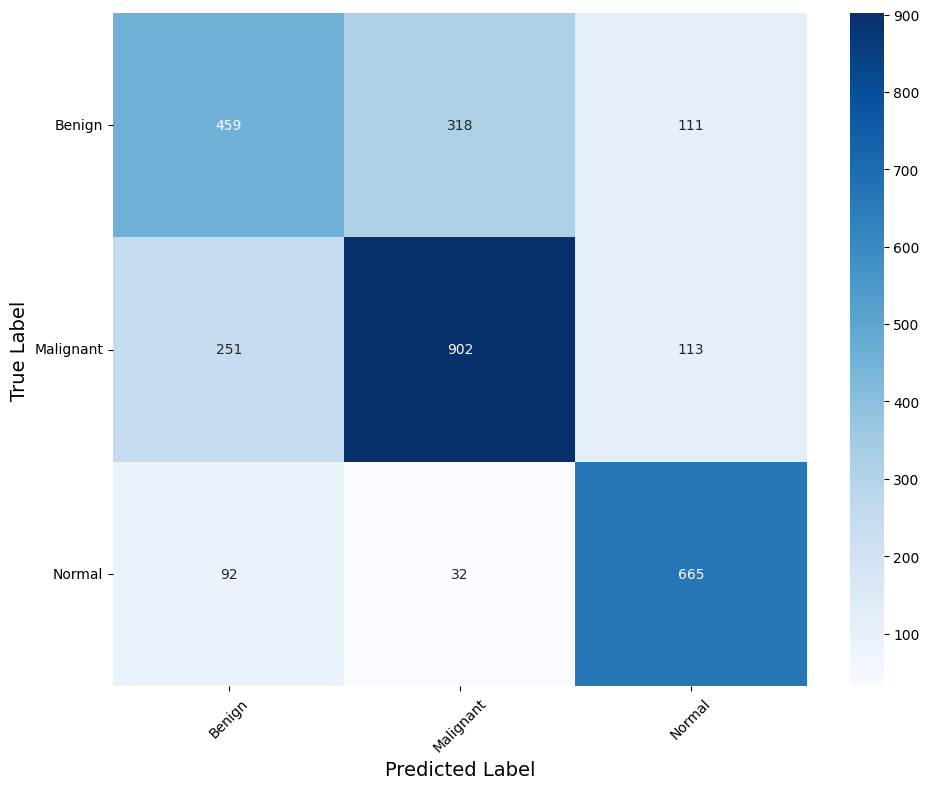

done1


In [28]:
# ==========================================================
# CONFUSION MATRIX (Test Set)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("ResNet50V2_LightGBM_confusion_matrix_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")


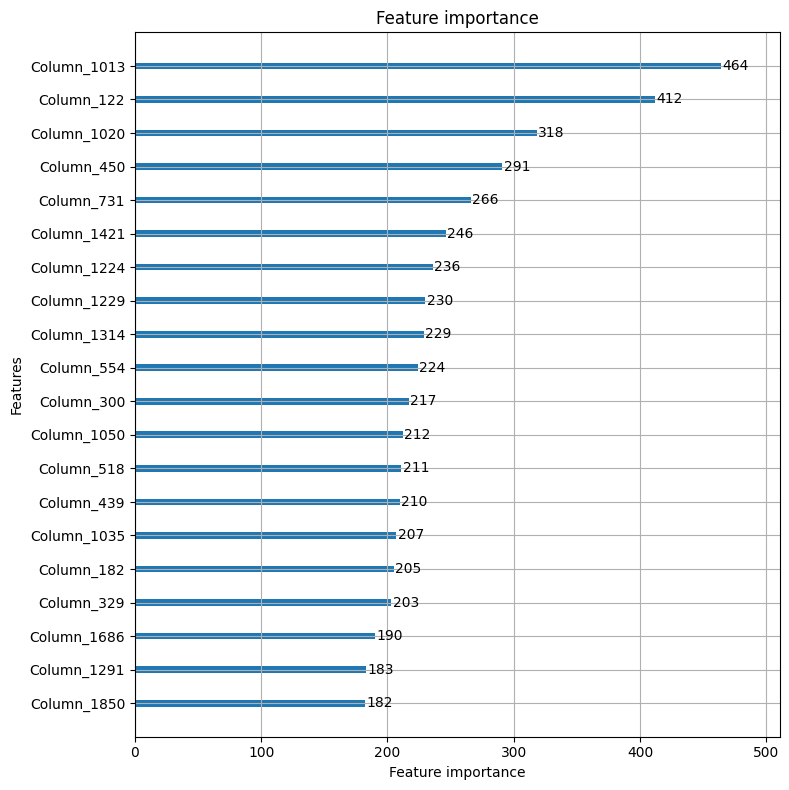

done


In [29]:
# ==========================================================
# LIGHTGBM FEATURE IMPORTANCE (bonus -- not in ResNet CNN pipelines,
# but a natural interpretability angle for the LightGBM stage of this hybrid)
# ==========================================================
lgb.plot_importance(lgb_model, max_num_features=20, figsize=(8, 8))
plt.tight_layout()
plt.savefig("ResNet50V2_LightGBM_feature_importance.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done")
